# MLP (Adam Optimizer)

## Import Library

In [18]:
# 1. IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from statsmodels.graphics.tsaplots import plot_acf
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

## Konfigurasi parameter
Mengatur seed untuk reproducibility dan mendefinisikan parameter utama untuk model dan proses training.

In [2]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Parameter
FILE_PATH = "bbri_2025.xlsx"
SHEET_NAME = 'Sheet1'
TARGET_COLUMN = 'Close'
EPOCHS = 100
BATCH_SIZE = 32
TUNER_MAX_TRIALS = 15
TUNER_EPOCHS = 50  # Bisa dikurangi saat tuning

In [3]:
def create_dataset_mlp(dataset, look_back=1):
    """
    Mengubah array nilai menjadi format dataset untuk MLP.
    Contoh:
    dataset = [1, 2, 3, 4, 5]
    look_back = 2
    Maka hasilnya:
    dataX = [[1, 2], [2, 3], [3, 4]]
    dataY = [3, 4, 5]
    """
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

## Persiapan data

In [4]:
from IPython.display import display, HTML

print(f"Memuat data dari {FILE_PATH} (Fitur: {TARGET_COLUMN})...")
df = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME,
    usecols=['Date', TARGET_COLUMN],
    parse_dates=['Date'],
    index_col='Date',
    engine='openpyxl'
)
df = df.dropna()
print("\nPreview Data:")
display(df.head())

dataset_values = df[TARGET_COLUMN].values.reshape(-1, 1).astype('float32')

Memuat data dari bbri_2025.xlsx (Fitur: Close)...

Preview Data:


,Close
Date,
2025-01-02,4210
2025-01-03,4150
2025-01-06,4100
2025-01-07,4030
2025-01-08,4080


<Figure size 1000x600 with 0 Axes>

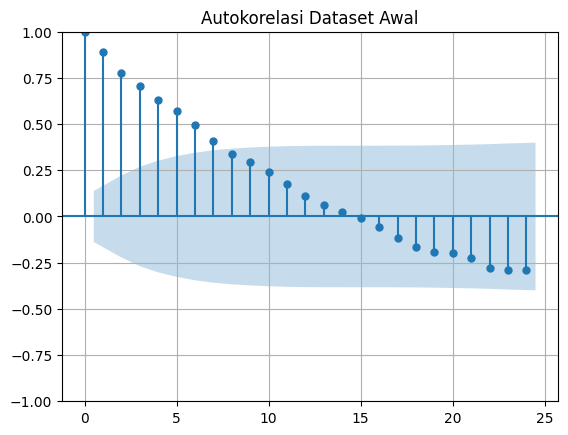

In [5]:
plt.figure(figsize=(10,6))
plot_acf(dataset_values, alpha=0.05)
plt.title('Autokorelasi Dataset Awal')
plt.grid(True)
plt.show()

### Preprocessing 
Split dataset menjadi train dan test, lakukan normalisasi, dan transformasi ke format supervised learning.

In [6]:
# Split dataset sebelum scaling
n_days = len(df)
test_size = 10
train_size = n_days - test_size

train_values = dataset_values[:train_size]
test_values  = dataset_values[train_size:]

# Fit scaler hanya pada data training
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_values)
scaled_train = scaler.transform(train_values)
scaled_test  = scaler.transform(test_values)

## Pemodelan

### Hyperparameter Tunning

In [7]:
best_overall_val_loss = float('inf')
best_look_back = None
best_hps = None
best_datasets = None

for lb in range(1, 6):
    print(f"\n--- Mencoba look_back = {lb} ---")
    
    X_train_lb, y_train_lb = create_dataset_mlp(scaled_train, lb)
    X_test_lb, y_test_lb   = create_dataset_mlp(scaled_test, lb)
    
    if len(X_train_lb) == 0 or len(X_test_lb) == 0:
        print(f"  Skip look_back={lb}: data tidak cukup.")
        continue

    def build_model_for_lb(hp):
        model = Sequential()
        hp_units = hp.Int('units_layer1', min_value=32, max_value=256, step=32)
        hp_layers = hp.Int('num_layers', min_value=1, max_value=3)
        hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

        model.add(Dense(hp_units, activation='relu', input_dim=lb))
        for i in range(hp_layers - 1):
            hp_units_hidden = hp.Int(f'units_layer_{i+2}', min_value=32, max_value=128, step=32)
            model.add(Dense(hp_units_hidden, activation='relu'))
        model.add(Dense(1))
        model.compile(
            optimizer=Adam(learning_rate=hp_lr),
            loss='mean_squared_error',
            metrics=['mae']
        )
        return model

    tuner_temp = kt.RandomSearch(
        build_model_for_lb,
        objective='val_loss',
        max_trials=TUNER_MAX_TRIALS,
        directory='kt_tuning_adam_lb',
        project_name=f'look_back_{lb}'
    )
    
    tuner_temp.search(
        X_train_lb, y_train_lb,
        epochs=TUNER_EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.15,
        callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
        shuffle=False,
        verbose=0
    )

    best_trial = tuner_temp.oracle.get_best_trials(1)[0]
    val_loss = best_trial.metrics.get_best_value('val_loss')
    print(f"  Validation Loss terbaik untuk lb={lb}: {val_loss:.6f}")
    
    if val_loss < best_overall_val_loss:
        best_overall_val_loss = val_loss
        best_look_back = lb
        best_hps = tuner_temp.get_best_hyperparameters(1)[0]
        best_datasets = (X_train_lb, y_train_lb, X_test_lb, y_test_lb)

print(f"\nlook_back terbaik: {best_look_back}")
print(f"Validation Loss terbaik: {best_overall_val_loss:.6f}")


--- Mencoba look_back = 1 ---

  Validation Loss terbaik untuk lb=1: 0.004873

--- Mencoba look_back = 2 ---
  Validation Loss terbaik untuk lb=2: 0.004809

--- Mencoba look_back = 3 ---
  Validation Loss terbaik untuk lb=3: 0.005160

--- Mencoba look_back = 4 ---
  Validation Loss terbaik untuk lb=4: 0.004753

--- Mencoba look_back = 5 ---
  Validation Loss terbaik untuk lb=5: 0.005216

look_back terbaik: 4
Validation Loss terbaik: 0.004753


### Definisi Arsitektur Model

In [8]:
X_train, y_train, X_test, y_test = best_datasets

def build_final_model(hp):
    model = Sequential()
    model.add(Dense(hp.get('units_layer1'), activation='relu', input_dim=best_look_back))
    for i in range(hp.get('num_layers') - 1):
        units = hp.get(f'units_layer_{i+2}')
        if units is not None:
            model.add(Dense(units, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=hp.get('learning_rate')), loss='mse')
    return model

model = build_final_model(best_hps)
print("\n--- Hyperparameter Terbaik ---")
print(f"Look Back      : {best_look_back}")
print(f"Learning Rate  : {best_hps.get('learning_rate')}")
print(f"Num Layers     : {best_hps.get('num_layers')}")
print(f"Units Layer 1  : {best_hps.get('units_layer1')}")
for i in range(2, best_hps.get('num_layers') + 1):
    print(f"Units Layer {i}  : {best_hps.get(f'units_layer_{i}')}")
print("------------------------------")

early_stopping_final = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


--- Hyperparameter Terbaik ---
Look Back      : 4
Learning Rate  : 0.01
Num Layers     : 3
Units Layer 1  : 224
Units Layer 2  : 64
Units Layer 3  : 32
------------------------------


### Training Model Final
Membangun dan melatih model dengan hyperparameter terbaik

In [9]:
early_stopping_final = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print(f"\nMulai training model FINAL (Epochs={EPOCHS})...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stopping_final],
    shuffle=False,
    verbose=1
)


Mulai training model FINAL (Epochs=100)...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.1087 - val_loss: 0.0191
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0229 - val_loss: 0.0113
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0156 - val_loss: 0.0153
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0145 - val_loss: 0.0105
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0117 - val_loss: 0.0128
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0111 - val_loss: 0.0081
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0098 - val_loss: 0.0085
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0093 - val_loss: 0.0072
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0090 - val_loss: 0.0056
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0084 - val_loss: 0.0055
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0082 - val_loss: 0.0060
Epoch 12/100
5/5 ━━━━━━━━━━━━━

### Visualisasi Loss training

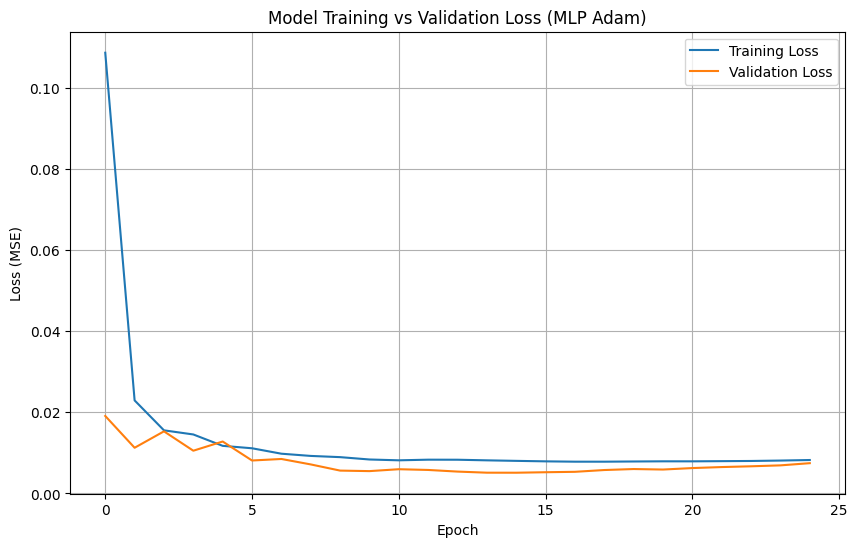

In [10]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training vs Validation Loss (MLP Adam)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

## Evaluasi model

### Prediksi dan invers transform

In [11]:
# Prediksi
train_predict = model.predict(X_train)
test_predict  = model.predict(X_test)

# Kembalikan ke skala asli
train_predict_orig = scaler.inverse_transform(train_predict)
test_predict_orig  = scaler.inverse_transform(test_predict)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig  = scaler.inverse_transform(y_test.reshape(-1, 1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


### Metrik evaluasi
Perhitungan RMSE, MAE, dan MAPE untuk mengukur akurasi model.

In [12]:
train_rmse = math.sqrt(mean_squared_error(y_train_orig, train_predict_orig))
train_rmse = math.sqrt(mean_squared_error(y_train_orig, train_predict_orig))
test_rmse = math.sqrt(mean_squared_error(y_test_orig, test_predict_orig))
train_mae = mean_absolute_error(y_train_orig, train_predict_orig)
test_mae = mean_absolute_error(y_test_orig, test_predict_orig)

epsilon = 1e-10
train_mape = np.mean(np.abs((y_train_orig - train_predict_orig) / (y_train_orig + epsilon))) * 100
test_mape = np.mean(np.abs((y_test_orig - test_predict_orig) / (y_test_orig + epsilon))) * 100

print(f"\n--- HASIL EVALUASI ---")
print(f"Train RMSE : {train_rmse:.2f}")
print(f"Test  RMSE : {test_rmse:.2f}")
print(f"Train MAE  : {train_mae:.2f}")
print(f"Test  MAE  : {test_mae:.2f}")
print(f"Train MAPE : {train_mape:.2f}%")
print(f"Test  MAPE : {test_mape:.2f}%")


--- HASIL EVALUASI ---
Train RMSE : 92.67
Test  RMSE : 50.29
Train MAE  : 70.63
Test  MAE  : 42.67
Train MAPE : 1.81%
Test  MAPE : 1.07%


### Visualisasi hasil prediksi

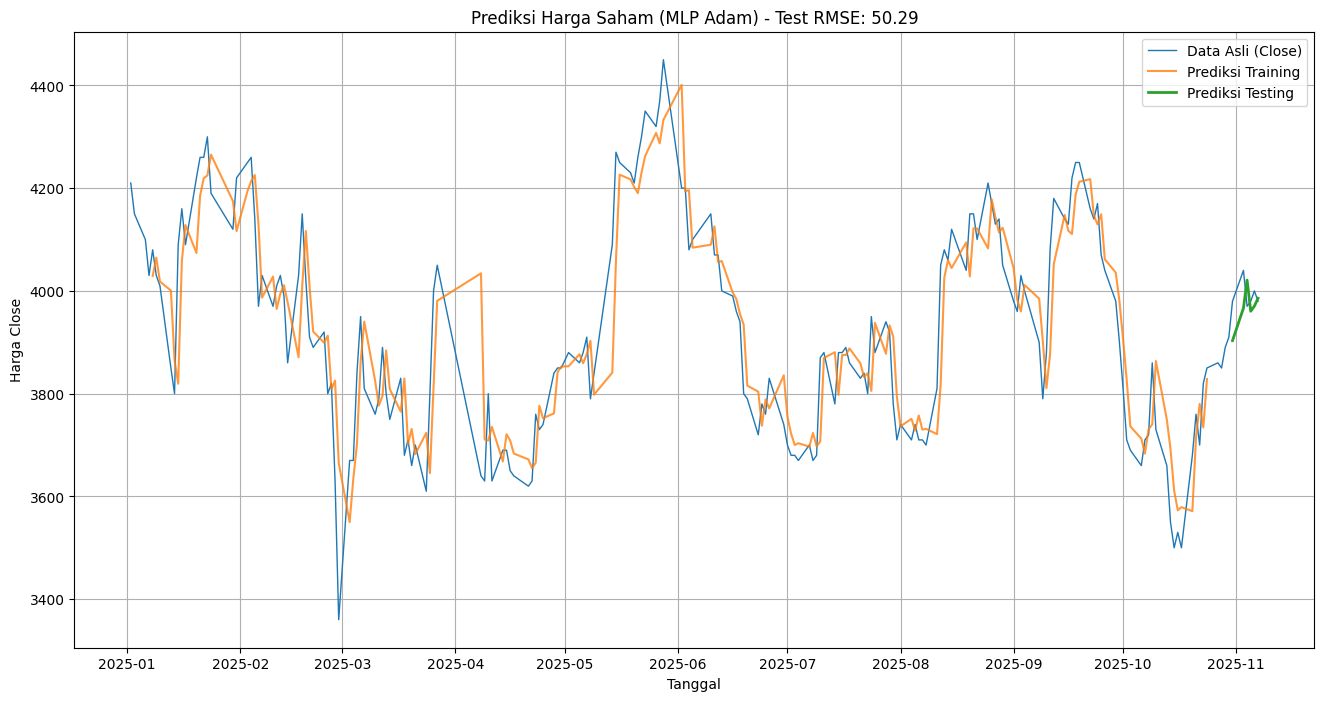

In [14]:
full_true = dataset_values.copy()
train_plot = np.empty_like(full_true)
train_plot[:] = np.nan
test_plot = np.empty_like(full_true)
test_plot[:] = np.nan

train_plot[best_look_back:best_look_back+len(train_predict_orig), 0] = train_predict_orig.flatten()
test_start = train_size + best_look_back
test_plot[test_start:test_start+len(test_predict_orig), 0] = test_predict_orig.flatten()

plt.figure(figsize=(16,8))
plt.plot(df.index, full_true, label='Data Asli (Close)', linewidth=1)
plt.plot(df.index, train_plot, label='Prediksi Training', alpha=0.8)
plt.plot(df.index, test_plot, label='Prediksi Testing', linewidth=2)
plt.title(f'Prediksi Harga Saham (MLP Adam) - Test RMSE: {test_rmse:.2f}')
plt.xlabel('Tanggal')
plt.ylabel('Harga Close')
plt.legend()
plt.grid(True)
plt.show()

### Autokorelasi residu

<Figure size 1000x600 with 0 Axes>

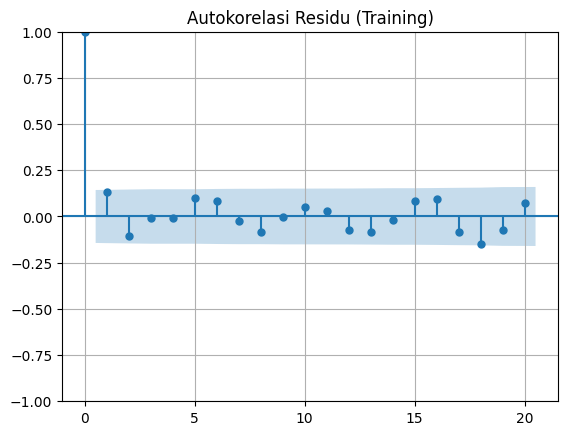

In [15]:
train_residuals = y_train_orig.flatten() - train_predict_orig.flatten()

plt.figure(figsize=(10,6))
plot_acf(train_residuals, lags=20, alpha=0.05)
plt.title('Autokorelasi Residu (Training)')
plt.grid(True)
plt.show()

### Cek White Noise dengan Ljung-box

In [16]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def diagnosis_ljungbox(residuals, title="Uji Ljung-Box"):
    print(f"--- {title} ---")
    lb_test = acorr_ljungbox(residuals, lags=[5, 10, 15, 20], return_df=True)
    print(lb_test)
    p_val_10 = lb_test.loc[10, 'lb_pvalue']
    if p_val_10 > 0.05:
        print(f"\nKesimpulan (Lag 10): ✅ LULUS (p-value {p_val_10:.4f} > 0.05)")
        print("Residu bersifat acak (White Noise). Model berhasil menangkap pola.")
    else:
        print(f"\nKesimpulan (Lag 10): ❌ GAGAL (p-value {p_val_10:.4f} < 0.05)")
        print("Residu TIDAK acak. Masih ada pola yang tertinggal di error.")
    print("-" * 50 + "\n")

diagnosis_ljungbox(train_residuals, "Diagnostik Residu Training (Adam)")

--- Diagnostik Residu Training (Adam) ---
      lb_stat  lb_pvalue
5    7.614740   0.178785
10  10.901552   0.365239
15  15.134161   0.441797
20  25.289515   0.190579

Kesimpulan (Lag 10): ✅ LULUS (p-value 0.3652 > 0.05)
Residu bersifat acak (White Noise). Model berhasil menangkap pola.
--------------------------------------------------



# MLP (SDG Optimizer)

## Pemodelan

### Hyperparameter Tunning

In [19]:
best_overall_val_loss_sgd = float('inf')
best_look_back_sgd = None
best_hps_sgd = None
best_datasets_sgd = None

for lb in range(1, 6):
    print(f"\n--- Mencoba look_back = {lb} (SGD) ---")
    
    X_train_lb, y_train_lb = create_dataset_mlp(scaled_train, lb)
    X_test_lb, y_test_lb   = create_dataset_mlp(scaled_test, lb)
    
    if len(X_train_lb) == 0 or len(X_test_lb) == 0:
        print(f"  Skip look_back={lb}: data tidak cukup.")
        continue

    def build_model_for_lb_sgd(hp):
        model = Sequential()
        hp_units = hp.Int('units_layer1', min_value=32, max_value=256, step=32)
        hp_layers = hp.Int('num_layers', min_value=1, max_value=3)
        hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        hp_momentum = hp.Choice('momentum', values=[0.0, 0.9, 0.99])

        model.add(Dense(hp_units, activation='relu', input_dim=lb))
        for i in range(hp_layers - 1):
            hp_units_hidden = hp.Int(f'units_layer_{i+2}', min_value=32, max_value=128, step=32)
            model.add(Dense(hp_units_hidden, activation='relu'))
        model.add(Dense(1))
        model.compile(
            optimizer=SGD(learning_rate=hp_lr, momentum=hp_momentum),
            loss='mean_squared_error',
            metrics=['mae']
        )
        return model
    
    tuner_temp_sgd = kt.RandomSearch(
        build_model_for_lb_sgd,
        objective='val_loss',
        max_trials=TUNER_MAX_TRIALS,
        directory='kt_tuning_sgd_lb',
        project_name=f'look_back_{lb}_sgd'
    )
    
    tuner_temp_sgd.search(
        X_train_lb, y_train_lb,
        epochs=TUNER_EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.15,
        callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
        shuffle=False,
        verbose=0
    )
    
    best_trial_sgd = tuner_temp_sgd.oracle.get_best_trials(1)[0]
    val_loss_sgd = best_trial_sgd.metrics.get_best_value('val_loss')
    print(f"  Validation Loss terbaik untuk lb={lb}: {val_loss_sgd:.6f}")

    if val_loss_sgd < best_overall_val_loss_sgd:
        best_overall_val_loss_sgd = val_loss_sgd
        best_look_back_sgd = lb
        best_hps_sgd = tuner_temp_sgd.get_best_hyperparameters(1)[0]
        best_datasets_sgd = (X_train_lb, y_train_lb, X_test_lb, y_test_lb)

print(f"\nlook_back terbaik (SGD): {best_look_back_sgd}")
print(f"Validation Loss terbaik (SGD): {best_overall_val_loss_sgd:.6f}")


--- Mencoba look_back = 1 (SGD) ---
  Validation Loss terbaik untuk lb=1: 0.005181

--- Mencoba look_back = 2 (SGD) ---
  Validation Loss terbaik untuk lb=2: 0.008890

--- Mencoba look_back = 3 (SGD) ---
  Validation Loss terbaik untuk lb=3: 0.006857

--- Mencoba look_back = 4 (SGD) ---
  Validation Loss terbaik untuk lb=4: 0.005809

--- Mencoba look_back = 5 (SGD) ---
  Validation Loss terbaik untuk lb=5: 0.006735

look_back terbaik (SGD): 1
Validation Loss terbaik (SGD): 0.005181


### Definisi Arsitektur Model

In [20]:
X_train_sgd, y_train_sgd, X_test_sgd, y_test_sgd = best_datasets_sgd

def build_final_model_sgd(hp):
    model = Sequential()
    model.add(Dense(hp.get('units_layer1'), activation='relu', input_dim=best_look_back_sgd))
    for i in range(hp.get('num_layers') - 1):
        units = hp.get(f'units_layer_{i+2}')
        if units is not None:
            model.add(Dense(units, activation='relu'))
    model.add(Dense(1))
    model.compile(
        optimizer=SGD(learning_rate=hp.get('learning_rate'), momentum=hp.get('momentum')),
        loss='mse'
    )
    return model

model_sgd = build_final_model_sgd(best_hps_sgd)
print("\n--- Hyperparameter Terbaik (SGD) ---")
print(f"Look Back      : {best_look_back_sgd}")
print(f"Learning Rate  : {best_hps_sgd.get('learning_rate')}")
print(f"Momentum       : {best_hps_sgd.get('momentum')}")
print(f"Num Layers     : {best_hps_sgd.get('num_layers')}")
print(f"Units Layer 1  : {best_hps_sgd.get('units_layer1')}")
for i in range(2, best_hps_sgd.get('num_layers') + 1):
    print(f"Units Layer {i}  : {best_hps_sgd.get(f'units_layer_{i}')}")
print("----------------------------------")


--- Hyperparameter Terbaik (SGD) ---
Look Back      : 1
Learning Rate  : 0.01
Momentum       : 0.9
Num Layers     : 2
Units Layer 1  : 160
Units Layer 2  : 96
----------------------------------


### Training Model Final

In [21]:
early_stopping_final_sgd = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print(f"\nMulai training model FINAL SGD (Epochs={EPOCHS})...")
history_sgd = model_sgd.fit(
    X_train_sgd, y_train_sgd,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stopping_final_sgd],
    shuffle=False,
    verbose=1
)


Mulai training model FINAL SGD (Epochs=100)...
Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - loss: 0.1245 - val_loss: 0.0186
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0302 - val_loss: 0.0782
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0483 - val_loss: 0.0243
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0154 - val_loss: 0.0184
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0200 - val_loss: 0.0156
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0149 - val_loss: 0.0235
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0169 - val_loss: 0.0187
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0129 - val_loss: 0.0134
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0122 - val_loss: 0.0128
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0117 - val_loss: 0.0139
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0117 - val_loss: 0.0129
Epoch 12/100
6/6 ━━━━━━━━

### Visualisasi Loss Training

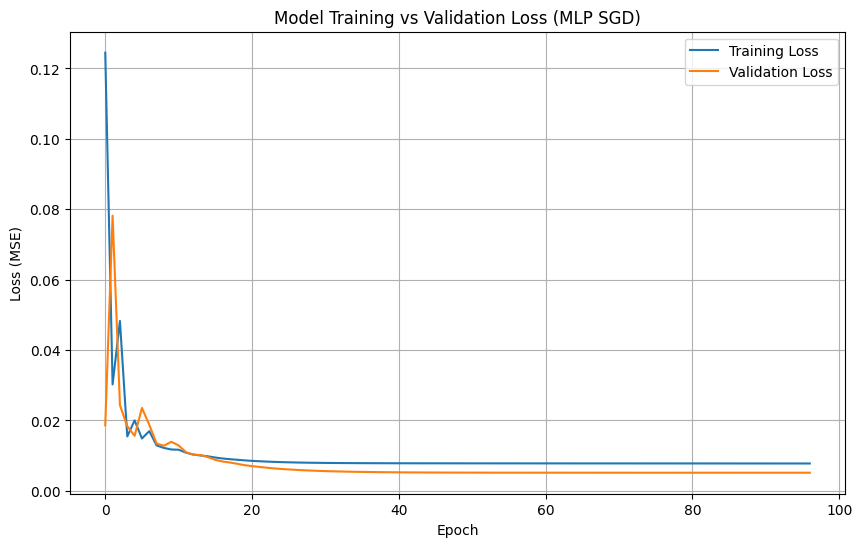

In [22]:
plt.figure(figsize=(10,6))
plt.plot(history_sgd.history['loss'], label='Training Loss')
plt.plot(history_sgd.history['val_loss'], label='Validation Loss')
plt.title('Model Training vs Validation Loss (MLP SGD)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

## Evaluasi Model

### Prediksi dan invers transform

In [23]:
train_predict_sgd = model_sgd.predict(X_train_sgd)
test_predict_sgd  = model_sgd.predict(X_test_sgd)

train_predict_orig_sgd = scaler.inverse_transform(train_predict_sgd)
test_predict_orig_sgd  = scaler.inverse_transform(test_predict_sgd)
y_train_orig_sgd = scaler.inverse_transform(y_train_sgd.reshape(-1, 1))
y_test_orig_sgd  = scaler.inverse_transform(y_test_sgd.reshape(-1, 1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


### Metrik Evaluasi

In [24]:
train_rmse_sgd = math.sqrt(mean_squared_error(y_train_orig_sgd, train_predict_orig_sgd))
test_rmse_sgd = math.sqrt(mean_squared_error(y_test_orig_sgd, test_predict_orig_sgd))
train_mae_sgd = mean_absolute_error(y_train_orig_sgd, train_predict_orig_sgd)
test_mae_sgd = mean_absolute_error(y_test_orig_sgd, test_predict_orig_sgd)

epsilon = 1e-10
train_mape_sgd = np.mean(np.abs((y_train_orig_sgd - train_predict_orig_sgd) / (y_train_orig_sgd + epsilon))) * 100
test_mape_sgd = np.mean(np.abs((y_test_orig_sgd - test_predict_orig_sgd) / (y_test_orig_sgd + epsilon))) * 100

print(f"\n--- HASIL EVALUASI (SGD) ---")
print(f"Train RMSE : {train_rmse_sgd:.2f}")
print(f"Test  RMSE : {test_rmse_sgd:.2f}")
print(f"Train MAE  : {train_mae_sgd:.2f}")
print(f"Test  MAE  : {test_mae_sgd:.2f}")
print(f"Train MAPE : {train_mape_sgd:.2f}%")
print(f"Test  MAPE : {test_mape_sgd:.2f}%")


--- HASIL EVALUASI (SGD) ---
Train RMSE : 93.44
Test  RMSE : 41.50
Train MAE  : 71.19
Test  MAE  : 35.04
Train MAPE : 1.83%
Test  MAPE : 0.88%


### Visualisasi Hasil Prediksi

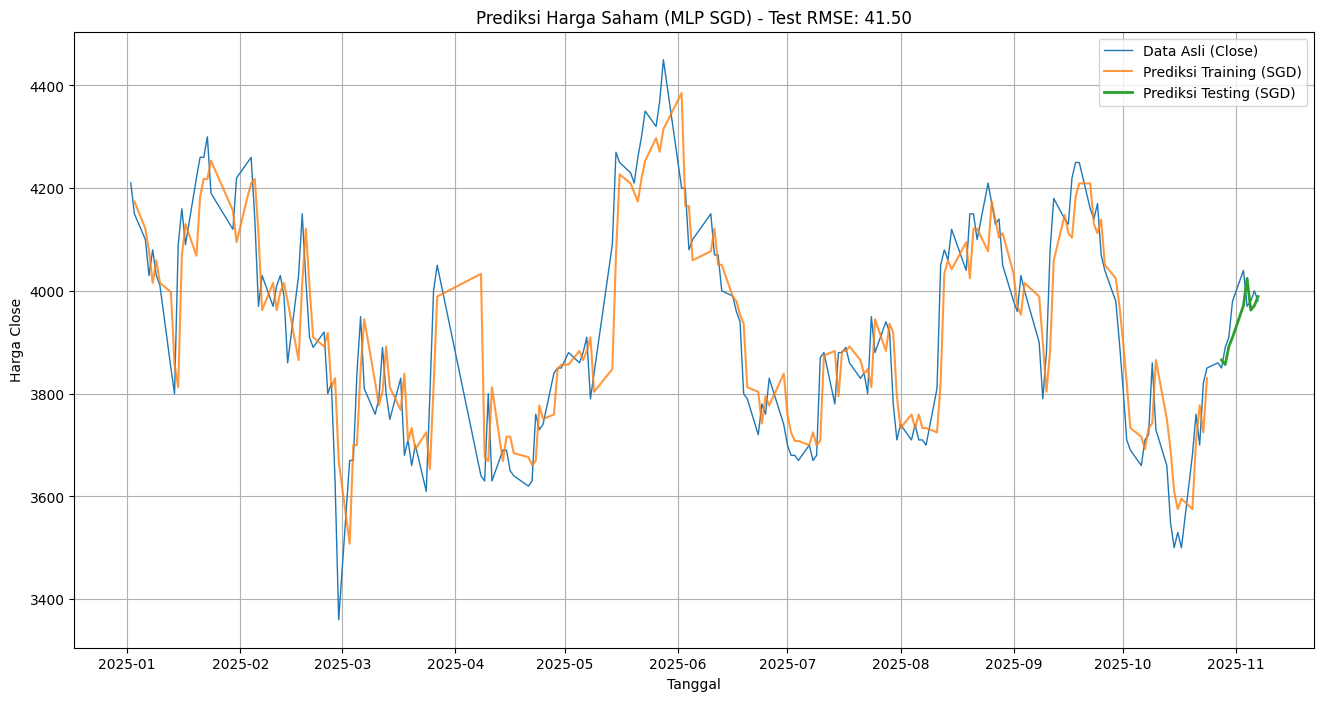

In [25]:
full_true_sgd = dataset_values.copy()
train_plot_sgd = np.empty_like(full_true_sgd)
train_plot_sgd[:] = np.nan
test_plot_sgd = np.empty_like(full_true_sgd)
test_plot_sgd[:] = np.nan

train_plot_sgd[best_look_back_sgd:best_look_back_sgd+len(train_predict_orig_sgd), 0] = train_predict_orig_sgd.flatten()
test_start_sgd = train_size + best_look_back_sgd
test_plot_sgd[test_start_sgd:test_start_sgd+len(test_predict_orig_sgd), 0] = test_predict_orig_sgd.flatten()

plt.figure(figsize=(16,8))
plt.plot(df.index, full_true_sgd, label='Data Asli (Close)', linewidth=1)
plt.plot(df.index, train_plot_sgd, label='Prediksi Training (SGD)', alpha=0.8)
plt.plot(df.index, test_plot_sgd, label='Prediksi Testing (SGD)', linewidth=2)
plt.title(f'Prediksi Harga Saham (MLP SGD) - Test RMSE: {test_rmse_sgd:.2f}')
plt.xlabel('Tanggal')
plt.ylabel('Harga Close')
plt.legend()
plt.grid(True)
plt.show()

### Autokorelasi Residu

<Figure size 1000x600 with 0 Axes>

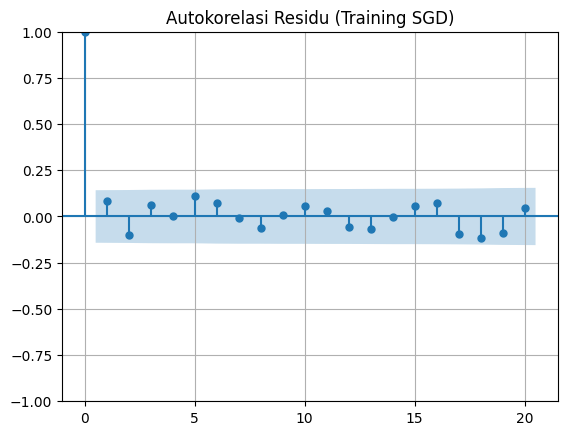

In [26]:
train_residuals_sgd = y_train_orig_sgd.flatten() - train_predict_orig_sgd.flatten()

plt.figure(figsize=(10,6))
plot_acf(train_residuals_sgd, lags=20, alpha=0.05)
plt.title('Autokorelasi Residu (Training SGD)')
plt.grid(True)
plt.show()

### Cek White Noise dengan Ljung-box

In [27]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def diagnosis_ljungbox_sgd(residuals, title="Uji Ljung-Box (SGD)"):
    print(f"--- {title} ---")
    lb_test = acorr_ljungbox(residuals, lags=[5, 10, 15, 20], return_df=True)
    print(lb_test)
    p_val_10 = lb_test.loc[10, 'lb_pvalue']
    if p_val_10 > 0.05:
        print(f"\nKesimpulan (Lag 10): ✅ LULUS (p-value {p_val_10:.4f} > 0.05)")
        print("Residu bersifat acak (White Noise). Model berhasil menangkap pola.")
    else:
        print(f"\nKesimpulan (Lag 10): ❌ GAGAL (p-value {p_val_10:.4f} < 0.05)")
        print("Residu TIDAK acak. Masih ada pola yang tertinggal di error.")
    print("-" * 50 + "\n")

diagnosis_ljungbox_sgd(train_residuals_sgd, "Diagnostik Residu Training (SGD)")

--- Diagnostik Residu Training (SGD) ---
      lb_stat  lb_pvalue
5    6.445147   0.265280
10   8.944717   0.537358
15  11.511673   0.715552
20  19.501208   0.489494

Kesimpulan (Lag 10): ✅ LULUS (p-value 0.5374 > 0.05)
Residu bersifat acak (White Noise). Model berhasil menangkap pola.
--------------------------------------------------

